In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.datasets import cifar10
from keras import layers

In [4]:
# Load data from cifar10 dataset
(X_train_orig, Y_train_orig), (X_test_orig, Y_test_orig) = cifar10.load_data()

Normalization is performed to **improve training speed**, **enhance stability**, and **boost overall performance** of deep learning models. In TensorFlow, both the **input** and **output** must be `tensors`, so it's critical to verify the shapes:
- The input data must be in the correct tensor shape.
- Output labels should be formatted as a **column vector**.

In [5]:
#Normalize image matrix
X_train = X_train_orig/255.0
X_test = X_test_orig/255.0

Y_train = Y_train_orig
Y_test = Y_test_orig

print ("number of training examples = " + str(X_train.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))

number of training examples = 50000
number of test examples = 10000
X_train shape: (50000, 32, 32, 3)
Y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
Y_test shape: (10000, 1)


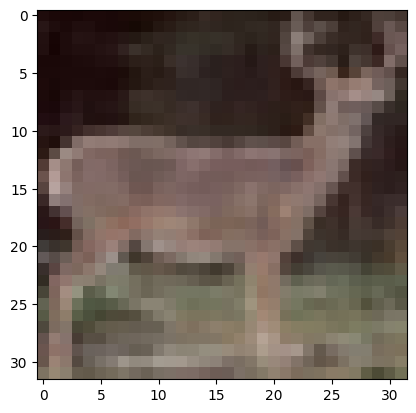

In [6]:
# plotting an training image
index = 665 
plt.imshow(X_train[index]) 
plt.show()

#### Simple CNN Model
We implemented a **function to build a simple CNN** that allows creating models with varying numbers of:
- **Filters** per convolutional layer.
- **Kernel sizes** (e.g., `(3,3)`, `(5,5)`).

This approach promotes reusability and makes it easy to experiment with different architectures.

In [7]:
def build_model_1(num_filters1=32, num_filters2=64, kernel_size=(3,3)):
    model = tf.keras.Sequential([
                tf.keras.layers.Conv2D(filters=num_filters1, kernel_size=kernel_size, activation='relu', input_shape=(32,32, 3), strides=(1,1), name='conv0'),
                tf.keras.layers.MaxPooling2D((2, 2), name='max_pool0'),
        
                tf.keras.layers.Conv2D(filters=num_filters2, kernel_size=kernel_size, activation='relu', strides=(1,1), name='conv1'),
                tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name='max_pool1'),
        
                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(128, activation='relu', name='fc1'),
                tf.keras.layers.Dense(10, activation='softmax', name='fc2'),
            ])
    return model

#### Complex CNN Model
We also implemented a **function for a more complex CNN**, which allows:
- Deeper network construction.
- Different numbers of **filters** and **kernel sizes** across layers.

In [8]:
def build_model_2(num_filters1=32, num_filters2=64, num_filters3=128, kernel_size=(3,3)):
    model = tf.keras.Sequential([
        layers.Conv2D(num_filters1, kernel_size, activation='relu', padding='same', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(num_filters2, kernel_size, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(num_filters3, kernel_size, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

### Training and Evaluation
A dedicated **training and evaluation function** has been implemented:
- Uses **SparseCategoricalCrossentropy** as the loss function (since the final layer has a **Softmax** activation).
- Returns:
  - `history`: A dictionary with `accuracy` and `loss` across epochs.
  - `test_loss`: Final loss value after testing.
  - `test_acc`: Final accuracy after testing.

In [9]:
def train_and_evaluate(model, epochs=5):
    model.compile(loss=SparseCategoricalCrossentropy(), metrics=['accuracy'])
    history = model.fit(X_train, Y_train, epochs=epochs)
    test_loss, test_acc = model.evaluate(X_test, Y_test)
    return history, test_loss, test_acc

### Model Variants Created from Simple CNN Model
Three simple CNN variants have been implemented:

1. **Model 1**:
    - Convolutional Layers:
        - 1st layer: **32 filters**
        - 2nd layer: **64 filters**
    - Kernel Size: **(3,3)**

2. **Model 2**:
    - Similar to Model 1, but with doubled filters:
        - 1st layer: **64 filters**
        - 2nd layer: **128 filters**

3. **Model 3**:
    - Similar to Model 1, but with a larger kernel size:
        - Kernel Size: **(5,5)**

In [11]:
# build, train and evaluate three different simple CNN models.

model1 = build_model_1(num_filters1=32, num_filters2=64, kernel_size=(3,3))
history1, test_loss1, test_acc1 = train_and_evaluate(model1)

model2 = build_model_1(num_filters1=64, num_filters2=128, kernel_size=(3,3))
history2, test_loss2, test_acc2 = train_and_evaluate(model2)

model3 = build_model_1(num_filters1=32, num_filters2=64, kernel_size=(5,5))
history3, test_loss3, test_acc3 = train_and_evaluate(model3)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.3620 - loss: 1.7456
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5978 - loss: 1.1389
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6678 - loss: 0.9570
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7164 - loss: 0.8252
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7473 - loss: 0.7329
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6956 - loss: 0.9492
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.4004 - loss: 1.6614
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6409 - loss: 1.0294
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7086 - loss: 0.8430
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.7555 - loss: 0.7169
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7926 - loss: 0.6055
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/

### Plotting Model Accuracy vs. Epochs for Simple CNN model

The figure below illustrates the **accuracy vs. epochs** for three different simple CNN models throughout the training and testing phases. 

- The **solid lines** represent the **training accuracy** across epochs.
- The **dashed lines** show the **testing accuracy** for each model.

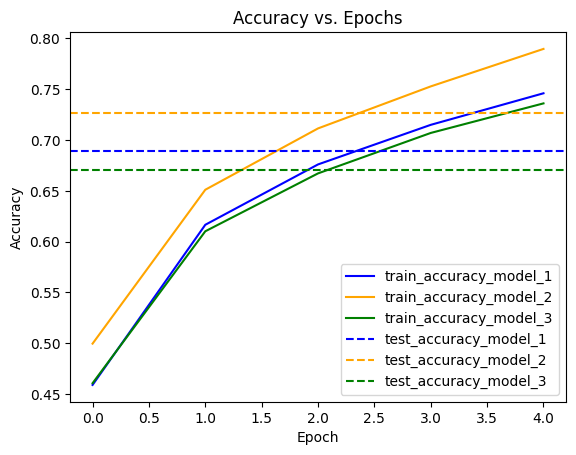

In [12]:
plt.plot(history1.history['accuracy'], color='blue', label='train_accuracy_model_1')
plt.plot(history2.history['accuracy'], color='orange', label='train_accuracy_model_2')
plt.plot(history3.history['accuracy'], color='green', label='train_accuracy_model_3')
plt.axhline(y=test_acc1, color='blue', linestyle='--', label='test_accuracy_model_1')
plt.axhline(y=test_acc2, color='orange', linestyle='--', label='test_accuracy_model_2')
plt.axhline(y=test_acc3, color='green', linestyle='--', label='test_accuracy_model_3')
plt.title("Accuracy vs. Epochs")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Plotting Model Loss vs. Epochs for Simple CNN Model

The figure below illustrates the **loss vs. epochs** for three different simple CNN models throughout the training and testing phases.

- The **solid lines** represent the **training loss** across epochs.
- The **dashed lines** show the **testing loss** for each model.

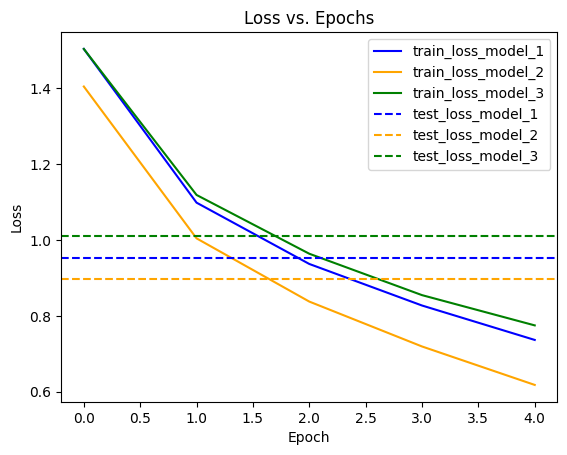

In [13]:
plt.plot(history1.history['loss'], color='blue', label='train_loss_model_1')
plt.plot(history2.history['loss'], color='orange', label='train_loss_model_2')
plt.plot(history3.history['loss'], color='green', label='train_loss_model_3')
plt.axhline(y=test_loss1, color='blue', linestyle='--', label='test_loss_model_1')
plt.axhline(y=test_loss2, color='orange', linestyle='--', label='test_loss_model_2')
plt.axhline(y=test_loss3, color='green', linestyle='--', label='test_loss_model_3')
plt.title("Loss vs. Epochs")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Model Variants Created from Complex CNN Model
Three CNN variants have been implemented:

1. **Model 1**:
    - Convolutional Layers:
        - 1st layer: **32 filters**
        - 2nd layer: **64 filters**
        - 3rd layer: **128 filters**
    - Kernel Size: **(3,3)**

2. **Model 2**:
    - Similar to Model 1, but with doubled filters:
        - 1st layer: **64 filters**
        - 2nd layer: **128 filters**
        - 3rd layer: **256 filters**

3. **Model 3**:
    - Similar to Model 1, but with a larger kernel size:
        - Kernel Size: **(5,5)**

In [14]:
# build, train and evaluate three different complex CNN models.

model1 = build_model_2(num_filters1=32, num_filters2=64, num_filters3=128, kernel_size=(3,3))
history1, test_loss1, test_acc1 = train_and_evaluate(model1)

model2 = build_model_2(num_filters1=64, num_filters2=128, num_filters3=256, kernel_size=(3,3))
history2, test_loss2, test_acc2 = train_and_evaluate(model2)

model3 = build_model_2(num_filters1=32, num_filters2=64, num_filters3=128, kernel_size=(5,5))
history3, test_loss3, test_acc3 = train_and_evaluate(model3)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.3295 - loss: 2.0865
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.4963 - loss: 1.4641
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.5473 - loss: 1.3302
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.5845 - loss: 1.2395
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6085 - loss: 1.1623
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5942 - loss: 1.2297
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 47ms/step - accuracy: 0.3107 - loss: 2.1910
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.4612 - loss: 1.5630
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.5063 - loss: 1.4627
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.5388 - loss: 1.3819
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.5717 - loss: 1.2895
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12m

### Plotting Model Accuracy vs. Epochs for complex CNN model

The figure below illustrates the **accuracy vs. epochs** for three different complex CNN models throughout the training and testing phases. 

- The **solid lines** represent the **training accuracy** across epochs.
- The **dashed lines** show the **testing accuracy** for each model.

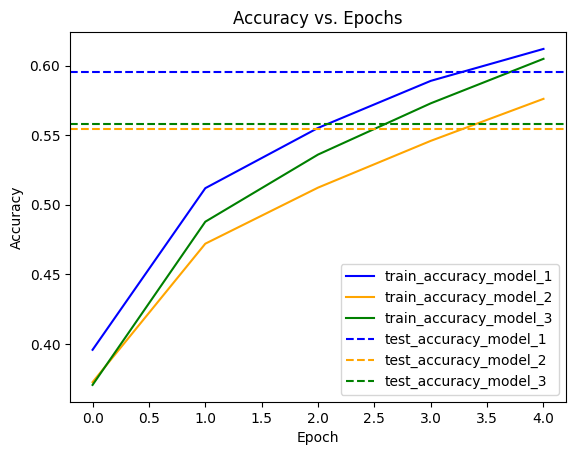

In [15]:
plt.plot(history1.history['accuracy'], color='blue', label='train_accuracy_model_1')
plt.plot(history2.history['accuracy'], color='orange', label='train_accuracy_model_2')
plt.plot(history3.history['accuracy'], color='green', label='train_accuracy_model_3')
plt.axhline(y=test_acc1, color='blue', linestyle='--', label='test_accuracy_model_1')
plt.axhline(y=test_acc2, color='orange', linestyle='--', label='test_accuracy_model_2')
plt.axhline(y=test_acc3, color='green', linestyle='--', label='test_accuracy_model_3')
plt.title("Accuracy vs. Epochs")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Plotting Model Loss vs. Epochs for Complex CNN Model

The figure below illustrates the **loss vs. epochs** for three different complex CNN models throughout the training and testing phases.

- The **solid lines** represent the **training loss** across epochs.
- The **dashed lines** show the **testing loss** for each model.

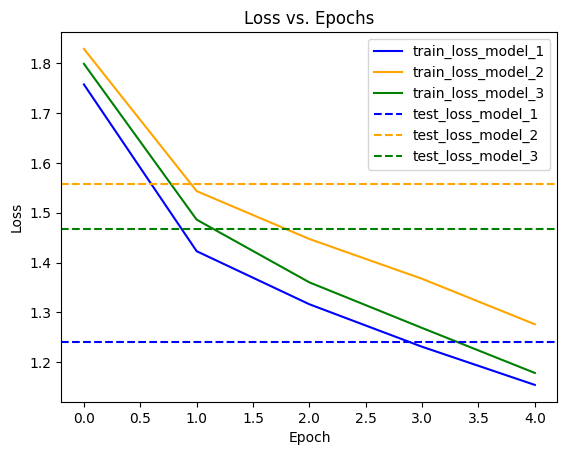

In [16]:
plt.plot(history1.history['loss'], color='blue', label='train_loss_model_1')
plt.plot(history2.history['loss'], color='orange', label='train_loss_model_2')
plt.plot(history3.history['loss'], color='green', label='train_loss_model_3')
plt.axhline(y=test_loss1, color='blue', linestyle='--', label='test_loss_model_1')
plt.axhline(y=test_loss2, color='orange', linestyle='--', label='test_loss_model_2')
plt.axhline(y=test_loss3, color='green', linestyle='--', label='test_loss_model_3')
plt.title("Loss vs. Epochs")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Conclusion for Model Accuracy

### Simple CNN Architecture
- **Model 1** (32, 64 filters across two convolution layers, kernel size = 3×3):  
  Achieved an accuracy **in between** Model 2 and Model 3.
- **Model 2** (64, 128 filters across two convolution layers, kernel size = 3×3):  
  Achieved the **highest accuracy**. This suggests that **increasing the number of filters** improves performance.
- **Model 3** (32, 64 filters across two convolution layers, kernel size = 5×5):  
  Achieved the **lowest accuracy**, suggesting that the **larger kernel size** negatively impacted performance.

### Complex CNN Architecture
- **Model 1** (32, 64, 128 filters across three convolution layers, kernel size = 3×3):  
  Achieved the **highest accuracy**, indicating that a balanced depth and smaller kernel sizes lead to better performance.
- **Model 3** (32, 64, 128 filters across three convolution layers, kernel size = 5×5):  
  Achieved an **accuracy in between** Model 1 and Model 2.
- **Model 2** (64, 128, 256 filters across three convolution layers, kernel size = 3×3):  
  Achieved the **lowest accuracy**, suggesting that merely increasing the number of filters doesn’t guarantee better performance in deeper models.

### Generalization Insights
Although the complex CNN architectures have slightly lower training accuracy, they demonstrate a **smaller drop-off** in test accuracy compared to the simple CNN models. This suggests that complex CNNs have **better generalization** capabilities despite lower training performance.

## Conclusion for Model Loss

### Simple CNN Architecture
- **Model 1** (32, 64 filters across two convolution layers, kernel size = 3×3):  
  Achieved a loss **in between** Model 2 and Model 3.
- **Model 2** (64, 128 filters across two convolution layers, kernel size = 3×3):  
  Achieved the **lowest loss**, indicating better optimization and learning due to increased filter depth.
- **Model 3** (32, 64 filters across two convolution layers, kernel size = 5×5):  
  Achieved the **highest loss**, suggesting that the larger kernel size negatively impacted the learning process.

### Complex CNN Architecture
- **Model 1** (32, 64, 128 filters across three convolution layers, kernel size = 3×3):  
  Achieved the **lowest loss**, aligning with its highest accuracy and indicating strong optimization.
- **Model 3** (32, 64, 128 filters across three convolution layers, kernel size = 5×5):  
  Achieved a **loss in between** Model 1 and Model 2.
- **Model 2** (64, 128, 256 filters across three convolution layers, kernel size = 3×3):  
  Achieved the **highest loss**, suggesting that deeper networks with more filters don’t necessarily guarantee lower loss or better performance.